<a href="https://colab.research.google.com/github/KHOORUIXIANG/AmplifAI-Bootcamp-Basics-of-Neutral-Networks/blob/CNN/Alexnet_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="W8AO6CHx2jaE4XIKg3Jr")
project = rf.workspace("sushicnn-mvtiv").project("nasi-lemak-vs-sushi-uucxy")
version = project.version(1)
dataset = version.download("folder")


loading Roboflow workspace...
loading Roboflow project...


In [3]:
!pip install torch

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# Seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Determine the device to use
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")


Running on device: cuda:0


In [12]:
# Define transformations
# Common standard mean and standard deviation for image normalization
# Resizing to 64x64 is a good size for a simple model
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Define transformations
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    # Normalize the tensor images
    transforms.Normalize(mean=MEAN, std=STD)
])

DATA_ROOT = '/content/Nasi-Lemak-vs-Sushi-1'

# 1. Create Image Datasets
try:
    # torchvision.datasets.ImageFolder automatically assigns labels based on folder names
    train_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, '/content/Nasi-Lemak-vs-Sushi-1/train'), transform=transform)
    test_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, '/content/Nasi-Lemak-vs-Sushi-1/test'), transform=transform)

    # Print class mapping (0=elephant, 1=giraffe, assuming lexicographical order)
    print("Class mapping:", train_dataset.class_to_idx)

    # 2. Create Data Loaders
    BATCH_SIZE = 128
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print(f"Loaded {len(train_dataset)} training images and {len(test_dataset)} testing images.")

except:
    print(f"Failed to Load Data!")



Class mapping: {'Nasi Lemak': 0, 'Sushi': 1}
Loaded 195 training images and 9 testing images.


In [13]:
class AlexNet(nn.Module):
    # This dataset has 2 classes (elephants, giraffes)
    def __init__(self, num_classes=2):
        super(AlexNet, self).__init__()

        # --- Adjusted Layer 1 for 64x64 input (less aggressive downsampling) ---
        # Input: 3x64x64. Output after Conv (K=5, S=2, P=0): (64-5)/2 + 1 = 30.5 -> 30.
        # Output: 32x30x30
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=0),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # Output after Pool (K=3, S=2): (30-3)/2 + 1 = 14.5 -> 14.
            # Final Output: 32x14x14
            nn.MaxPool2d(kernel_size = 3, stride = 2))

        # --- Layer 2 (Input channels corrected from 96 to 32) ---
        # Input: 32x14x14. Output after Conv (K=5, S=1, P=2): (14-5+4)/1 + 1 = 14.
        # Output: 256x14x14
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 256, kernel_size=5, stride=1, padding=2), # Fixed: 96 -> 32
            nn.BatchNorm2d(256),
            nn.ReLU(),
            # Output after Pool (K=3, S=2): (14-3)/2 + 1 = 6.5 -> 6.
            # Final Output: 256x6x6
            nn.MaxPool2d(kernel_size = 3, stride = 2))

        # --- Layer 3 (Dimensions continue from 256x6x6) ---
        # Output: 384x6x6
        self.layer3 = nn.Sequential(
            nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU())

        # --- Layer 4 ---
        # Output: 384x6x6
        self.layer4 = nn.Sequential(
            nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU())

        # --- Layer 5 (Input: 384x6x6) ---
        # Output after Conv: 256x6x6
        self.layer5 = nn.Sequential(
            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            # Output after Pool (K=3, S=2): (6-3)/2 + 1 = 2.5 -> 2.
            # Final Output: 256x2x2
            nn.MaxPool2d(kernel_size = 3, stride = 2))

        # Flattened size is 256 * 2 * 2 = 1024
        FINAL_FLATTEN_SIZE = 256 * 2 * 2

        # --- Fully Connected Layers (Input size corrected from 9216 to 1024) ---
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(FINAL_FLATTEN_SIZE, 4096), # Fixed: 9216 -> 1024
            nn.ReLU())

        self.fc1 = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU())

        self.fc2= nn.Sequential(
            nn.Linear(4096, num_classes))

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.layer5(out)

        # Reshape for the fully connected layers
        out = out.reshape(out.size(0), -1)

        out = self.fc(out)
        out = self.fc1(out)
        out = self.fc2(out)
        return out

In [14]:
## 4. Loss Function and Optimizer
# Instantiate the model and move it to the device (CPU/GPU)
model = AlexNet(num_classes=2).to(device)
# model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
print(model)

#We use CrossEntropyLoss, which is standard for multi-class classification and combines `LogSoftmax` and `NLLLoss` for better numerical stability.
# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


AlexNet(
  (layer1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(2, 2))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer4): Sequential(
    (0): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )


In [15]:
## 5. Training Function

#This function iterates through the dataset for a specified number of epochs.

def train_model(model, train_loader, criterion, optimizer, num_epochs=10):
    model.train() # Set the model to training mode

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for i, (inputs, labels) in enumerate(train_loader):
            # Move data to the selected device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total

        print(f'Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%')

    print('Finished Training.')
    return model


NUM_EPOCHS = 80
# Start training
trained_model = train_model(model, train_loader, criterion, optimizer, num_epochs=NUM_EPOCHS)


Epoch 1/80 | Loss: 1.3580 | Accuracy: 52.82%
Epoch 2/80 | Loss: 14.4285 | Accuracy: 46.15%
Epoch 3/80 | Loss: 0.8839 | Accuracy: 54.87%
Epoch 4/80 | Loss: 0.6097 | Accuracy: 68.21%
Epoch 5/80 | Loss: 0.7071 | Accuracy: 55.90%
Epoch 6/80 | Loss: 0.5967 | Accuracy: 72.31%
Epoch 7/80 | Loss: 0.5853 | Accuracy: 77.44%
Epoch 8/80 | Loss: 0.5263 | Accuracy: 77.44%
Epoch 9/80 | Loss: 0.4736 | Accuracy: 77.95%
Epoch 10/80 | Loss: 0.4918 | Accuracy: 78.97%
Epoch 11/80 | Loss: 0.4317 | Accuracy: 83.08%
Epoch 12/80 | Loss: 0.4254 | Accuracy: 84.10%
Epoch 13/80 | Loss: 0.4016 | Accuracy: 85.13%
Epoch 14/80 | Loss: 0.3372 | Accuracy: 87.18%
Epoch 15/80 | Loss: 0.3042 | Accuracy: 88.72%
Epoch 16/80 | Loss: 0.3024 | Accuracy: 88.72%
Epoch 17/80 | Loss: 0.2795 | Accuracy: 89.23%
Epoch 18/80 | Loss: 0.2744 | Accuracy: 91.28%
Epoch 19/80 | Loss: 0.2371 | Accuracy: 91.28%
Epoch 20/80 | Loss: 0.2895 | Accuracy: 90.26%
Epoch 21/80 | Loss: 0.2201 | Accuracy: 91.79%
Epoch 22/80 | Loss: 0.2535 | Accuracy: 91.

In [18]:
def test_model(model, test_loader):
    model.eval() # Set the model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad(): # Disable gradient calculation for inference
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            # Get the predicted class (index of the max log-probability)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'\nModel Accuracy on Test Set: {accuracy:.2f}% ({correct}/{total})')

# Test the final model
test_model(trained_model, test_loader)



Model Accuracy on Test Set: 88.89% (8/9)


--------------------------------------------------
Selected Image Index: 0
True Label: NASI LEMAK
Predicted Label: NASI LEMAK
--------------------------------------------------


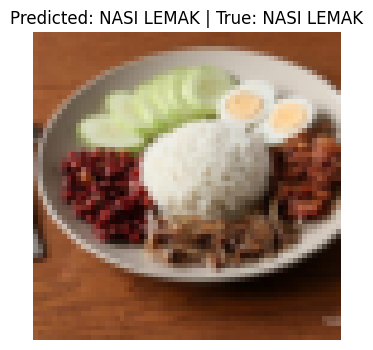

In [17]:
def unnormalize_tensor(tensor, mean, std):
    """Reverses the normalization for plotting."""
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor


def predict_example_image(model, dataset):

    model.eval()
    # 1. Select a random image index
    random_index = random.randint(0, len(dataset) - 1)

    # 2. Get the image tensor and true label
    image_tensor, true_label = dataset[random_index]

    # 3. Prepare image for model (add batch dimension and move to device)
    input_tensor = image_tensor.unsqueeze(0).to(device)

    # 4. Run inference
    with torch.no_grad():
        output = model(input_tensor)
        # Get the predicted class index
        _, predicted_index = torch.max(output, 1)

    # 5. Get the class names
    classes = dataset.classes
    true_class = classes[true_label]
    predicted_class = classes[predicted_index.item()]

    # 6. Display the result
    print("-" * 50)
    print(f"Selected Image Index: {random_index}")
    print(f"True Label: {true_class.upper()}")
    print(f"Predicted Label: {predicted_class.upper()}")
    print("-" * 50)

    # 7. Plot the image
    # Clone and unnormalize the tensor for visualization
    img_for_plot = image_tensor.clone().cpu()
    unnormalize_tensor(img_for_plot, MEAN, STD)

    # PyTorch tensors are (C, H, W), Matplotlib needs (H, W, C)
    npimg = img_for_plot.numpy()
    plt.figure(figsize=(4, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(f"Predicted: {predicted_class.upper()} | True: {true_class.upper()}")
    plt.axis('off')
    plt.show()

# Run the prediction on a random sample from the test set
predict_example_image(trained_model, test_dataset)